# Statistical Properties of Financial Security Returns

This notebook covers financial returns and their statistical properties. This is an essential building block for more advanced financial analysis. In theory, you should be familiar with most of the definitions and concepts in this notebook, save perhaps for the distributional properties of estimates of means, variances, skew and kurtosis. We will use stock prices and returns as a working example, but you should understand that the same definitions are relevant for other financial security returns such as government and corporate bonds, currencies, and commodities.


## Learning Objectives

By the end of this notebook, you should be able to:

1. Define and distinguish alternative notions of a security return -- simple vs. log, single-period vs. multiperiod -- and compute each from raw price (and dividend) data.
2. Read historical security price/return data into a Pandas DataFrame and reshape it for analysis.
3. Produce and interpret basic price/return time-series visualizations, including cumulative return plots.
4. Compute and interpret standard descriptive statistics for a return series: mean, standard deviation, skewness, and kurtosis.
5. Explain what "moments" of a distribution are (mean, variance, skew, kurtosis) and why each one matters for characterizing risk in financial markets.
6. Estimate these moments from sample data using Pandas, and understand the "plug-in principle" behind these estimators.
7. Use a Q-Q plot to informally assess whether a return series appears normally distributed, and explain why a graphical diagnostic can reveal structure that summary statistics like skewness and kurtosis can obscure.


## Extreme Outcomes in Financial Markets

Why should we care about more than just the *average* return on a security? Because markets regularly deliver outcomes far from the average -- and those outcomes can be economically enormous.

Consider crude oil -- or rather, a simple way of holding it. **USO** (the United States Oil Fund) is an exchange-traded fund whose objective is for its share price to track the daily percentage changes in the spot price of West Texas Intermediate (WTI) light, sweet crude oil delivered to Cushing, Oklahoma. You can buy and sell USO shares exactly like a stock -- no futures contract to manage, no expiration date, no margin account. (Under the hood, USO actually pursues this tracking by holding front-month NYMEX WTI futures contracts, so it is still fundamentally a derivatives-based vehicle -- and that mechanism can occasionally cause USO's returns to diverge from the spot price of oil, most dramatically when WTI futures famously turned *negative* for a day in April 2020. We'll set that wrinkle aside for now and treat USO as our oil proxy.)

In late February 2026, USO was trading around `$80`/share -- a level consistent with a fairly calm market. On February 27, 2026, U.S. and Israeli military operations against Iran began. Iran responded by threatening, and then carrying out, attacks on commercial shipping in the Strait of Hormuz -- a chokepoint through which a large share of the world's seaborne oil trade passes -- and on March 4, 2026, Iranian forces declared the Strait "closed."

The chart below shows roughly six calm months leading up to the crisis, followed by what happened once it hit, using actual daily closing prices for USO and, for contrast, the SPY ETF (which tracks the S&P 500). In about a week, USO moved from `$79.77`/share to `$91.56`/share -- a jump of roughly 14.8%. Within about six weeks it had climbed to nearly `$139`/share, as the conflict escalated into what the International Energy Agency later described as the largest disruption to seaborne oil supply in the history of the global oil market. SPY, meanwhile, barely reacted -- moving less than 1% over that same first week. That contrast is itself informative: the shock was concentrated in the oil market, not broad-based across all risky assets.

This doesn't mean equities are immune to extreme, sudden moves -- just that this particular episode happened to be concentrated in oil. Equity markets have their own history of single-day shocks: for example, SPY itself surged more than 10% in a single day in April 2025, on news of a pause in tariff escalation -- one of the largest one-day moves in the ETF's history. Extreme outcomes show up across financial markets; they just don't all show up at the same time, or for the same reason. We'll come back to SPY's own extreme days later in this notebook, once we have the tools to look for them systematically. By mid-2026, after a ceasefire and then a renewed flare-up, oil prices had settled back down considerably -- still well above where they started, and still moving sharply on any new development.

*Source: daily closing prices for USO and the SPY ETF, retrieved from Yahoo Finance; see `data/uso_etf_daily.csv` and `data/spy_etf_daily.csv`. USO's investment objective: United States Oil Fund, LP prospectus (SEC EDGAR); USCF Investments, "USO | The Original Oil ETF." Event background: Congressional Research Service, "The Strait of Hormuz: Security Developments and Impacts on Oil, Gas, and Other Commodities" (2026); J.P. Morgan Global Research, "US-Israel Military Operation Against Iran: Are Markets on Edge?"*

**Why this matters to an investor.** Suppose you had bought 100 shares of USO on February 26, 2026 -- roughly `$7,977` worth -- perhaps as a hedge against rising energy costs, or simply a bet that oil prices would recover. Just a week later, that position would already be worth about `$1,179` more, and considerably more within six weeks as USO kept climbing. An investor who instead *shorted* USO over the same window -- perhaps betting prices would stay range-bound -- would have suffered a comparably large, sudden loss. The code cells below load the data, draw the chart, and work out this arithmetic.

The point isn't which side of the trade was "right." It's that **sudden, dramatic changes in value are a regular, recurring feature of financial and commodity markets** -- not a rare curiosity confined to textbook examples. Wars, pandemics, central bank surprises, and firm-specific news all generate returns that a "typical" trading day would give you no reason to expect.

This raises the central question for the rest of this notebook: *what probability and statistical tools do we need in order to describe, and reason carefully about, a distribution of returns that regularly produces outcomes like this one?* We'll start with the basic building blocks -- return definitions -- and then build toward the tools (moments, and eventually the idea of "fat tails") that let us talk about this kind of risk precisely.


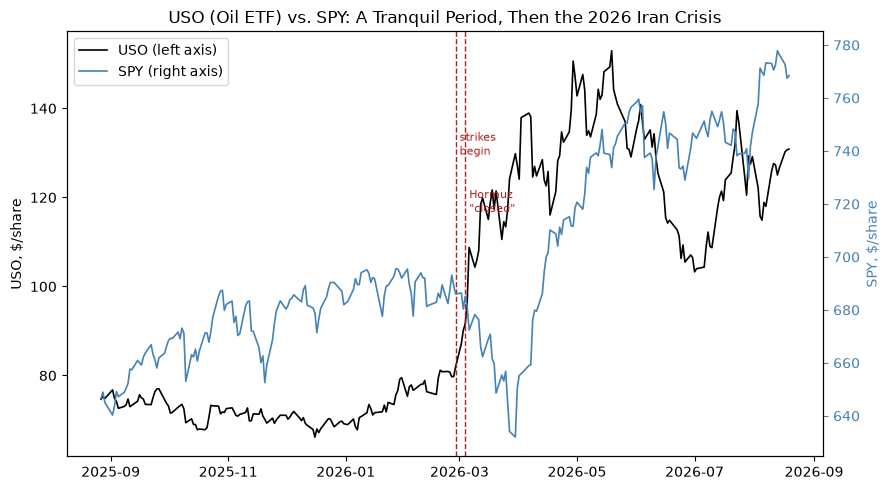

In [1]:
# Daily closing prices, retrieved from Yahoo Finance:
#   - USO, the United States Oil Fund (an ETF designed to track WTI crude oil)
#   - SPY, the SPDR S&P 500 ETF Trust (shown for contrast: the broad market)
# Small illustrative extracts -- see data/uso_etf_daily.csv and
# data/spy_etf_daily.csv for the source data and citation.
import pandas as pd
import matplotlib.pyplot as plt

uso = pd.read_csv("../data/uso_etf_daily.csv", parse_dates=["date"]).set_index("date")
spy = pd.read_csv("../data/spy_etf_daily.csv", parse_dates=["date"]).set_index("date")

# For the chart, zoom in on roughly six tranquil months before the crisis
# onset, plus the crisis itself and its aftermath through the present.
plot_start = "2025-08-27"
uso_window = uso.loc[plot_start:]
spy_window = spy.loc[plot_start:]

onset_date = pd.Timestamp("2026-02-27")   # US/Israeli strikes on Iran begin
closure_date = pd.Timestamp("2026-03-04")  # Iran declares the Strait of Hormuz "closed"

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(uso_window.index, uso_window["close_usd"], color="black", linewidth=1.2, label="USO (left axis)")
ax1.set_ylabel("USO, $/share")

ax2 = ax1.twinx()
ax2.plot(spy_window.index, spy_window["close_usd"], color="steelblue", linewidth=1.2, label="SPY (right axis)")
ax2.set_ylabel("SPY, $/share", color="steelblue")
ax2.tick_params(axis="y", colors="steelblue")

ax1.axvline(onset_date, color="firebrick", linestyle="--", linewidth=1)
ax1.axvline(closure_date, color="firebrick", linestyle="--", linewidth=1)
ax1.text(onset_date, 135, " strikes\n begin", color="firebrick", fontsize=8, va="top")
ax1.text(closure_date, 122, " Hormuz\n \"closed\"", color="firebrick", fontsize=8, va="top")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("USO (Oil ETF) vs. SPY: A Tranquil Period, Then the 2026 Iran Crisis")
plt.tight_layout()
plt.show()

In [2]:
# Illustrative P&L: a hypothetical USO position held across the initial
# shock, using the actual USO closes loaded above.

shares = 100
price_before = uso.loc["2026-02-26", "close_usd"]  # last close before the conflict began
price_after  = uso.loc["2026-03-04", "close_usd"]   # the day the Strait of Hormuz was declared "closed"

pct_change = price_after / price_before - 1
value_change = (price_after - price_before) * shares

print(f"USO: ${price_before:.2f} (Feb 26) -> ${price_after:.2f} (Mar 4)")
print(f"Percent change in USO: {pct_change:.1%}")
print(f"Value change on a LONG position of {shares} shares:  ${value_change:,.0f}")
print(f"Value change on a SHORT position of {shares} shares: -${value_change:,.0f}")
print()
print("...and this was just the first week. Within about six weeks, USO had")
print("climbed to nearly $139/share as the conflict escalated further (see the chart above).")

USO: $79.77 (Feb 26) -> $91.56 (Mar 4)
Percent change in USO: 14.8%
Value change on a LONG position of 100 shares:  $1,179
Value change on a SHORT position of 100 shares: -$1,179

...and this was just the first week. Within about six weeks, USO had
climbed to nearly $139/share as the conflict escalated further (see the chart above).


With that motivation in hand, let's build up the formal machinery, starting with some key definitions.

## Background and definitions

We start with some key definitions:  

Price = the price of a traded financial security, such as a stock, bond, ETF, commodity, etc. 

Mathematically, we will denote the price as $P_{t}$, where the t-subscript represents a particular time. So, $P_{1}, P_{2}, P_{3},...$ denotes the price of a particular stock or other security at times 1, 2, 3, and so on. The units of time depend on the setting, and might be days, months, quarters, years, etc. 

Note: if we are considering multiple securities, such as IBM and GE stock, then we might use notation like $P_{IBM,t}$ and $P_{GE,t}$ to denote the prices of IBM and GE, respectively, on date $t$.

We will assume that prices are always positive. This allows us to take the natural logarithm. The log price is denoted $p_{t} \equiv \ln(P_{t})$. The reason for wanting to consider log prices will be explained below.

Some assets pay periodic cash flows to the holder. For example, some stocks pay regular dividends to shareholders, and some bonds pay periodic coupons to the holder. Mathematically, let $D_{t}$ denote the cash received by the holder of a stock (or other asset) at time $t$. 


## Key return definitions
### Periodic return

Period return formula: $R_{t} \equiv \frac{P_{t} + D_{t} - P_{t-1}}{P_{t-1}} = \frac{P_{t} + D_{t}}{P_{t-1}} - 1 = \frac{P_{t} - P_{t-1}}{P_{t-1}} + \frac{D_{t}}{P_{t-1}}$

The third equality shows that the periodic return can be decomposed into two terms: 1) capital gain and 2) dividend yield.

The return $R_{t}$ defined above is sometimes called the *simple net return* whereas $1 + R_{t}$ is the *simple gross return*. As a simple quantitative example, suppose the price goes from 100 to 105 during a period with no dividends. Then the simple gross return is $1+R_{t} = \frac{105}{100} = 1.05$ and the simple net return is $R_{t} = 1.05 - 1 = 0.05$ or 5%. 

*Technical note*: In the periodic return formula above, the component $D_{t}$ should technically equal the cumulative, re-invested value of all cash flows/dividends received by the investor during the holding period. To understand the issue here, imagine computing the periodic return over one year for a corporate bond that pays a quarterly coupon. The $D_{t}$ component in the return formula in this case should equal the re-invested value of all coupons received during that year. Similar comments would apply to the annual return for a stock that pays quarterly dividends. 


### Log return
Suppose for a moment that the dividend is zero ($D_{t} = 0$). Then the log return can be computed as:

$r_{t} \equiv \ln(P_{t}/P_{t-1}) = p_{t} - p_{t-1}$. (Remember that $p_{t} = \ln(P_{t})$.)

*Often, in practice, we can obtain special price series that effectively include paid dividends.* For example, Yahoo! finance provides an "Adjusted close" price series that incorporates the effects of both dividends and potential stock split events. This is convenient because we can then take $D_{t} = 0$ in return computations. It is particularly convenient for log returns, because as shown above, the log return is simply the difference of (dividend-adjusted) log prices.


### Multiperiod returns

What if a stock is held for multiple days, or months? For simplicity, let us assume that the asset does not pay a dividend. (This is not as unrealistic as it might seem -- many publicly listed companies on Nasdaq and even NYSE have not paid a dividend and are unlikely to do so in the near term.)

Without dividends, the one-period gross return is $1 + R_{t} = \frac{P_{t}}{P_{t-1}}$. Now, let us define the $k$-period gross return as the gross return from period $t-k$ to $t$, or $1+R_{t}(k)$ in notation. This is:

$1+R_{t}(k) = (1+R_{t-k+1})(1+R_{t-k+2})...(1+R_{t}) = \frac{P_{t}}{P_{t-k}}$. The net $k$ period return subtracts one from the previous definition.

Multiperiod annual returns are often expressed on an *annualized* basis for interpretation as follows:

Annualized $R_{t}(k) = [\prod_{j=0}^{k-1}(1+R_{t-j})]^{1/k}-1$

Log returns are very convenient in the multiperiod case. By taking the log of the $k$ period gross return formula above, it is straightforward to verify that the $k$-period log return is just the sum of the period-by-period log returns:

$r_{t}(k) = r_{t-k+1} + r_{t-k+2} + ... + r_{t}$

If the period interval is one year, then we can annualize the log-multiyear return by simply averaging the log returns over the years in question.

Finally, the convenience of log returns for the multiperiod case extends to a setting with dividends. However, there is a complication in the sense that the log return is a nonlinear function of log prices and dividends:

$r_{t} = \ln(P_{t} +  D_{t}) - \ln(P_{t-1})$





## Taking it to the data

Let's take the previous concepts to the data. For the remainder of this notebook we'll work with the same two securities from the motivating example above:

1. **USO**: an ETF designed to track the price of WTI crude oil (our proxy for "the oil market")
2. **SPY**: an ETF that tracks the S&P 500 index (our proxy for "the broad stock market")

Both are freely traded, publicly available securities. Unlike CRSP/WRDS-sourced stock data -- which is licensed, and which this repository is not permitted to redistribute -- we can simply retrieve and store a small extract of USO's and SPY's daily closing prices directly in this repository (see `data/uso_etf_daily.csv` and `data/spy_etf_daily.csv`, both retrieved from Yahoo Finance). One practical benefit: every cell in this notebook can now be run without needing WRDS access.

The data below cover a longer window than the motivating example above -- roughly six years, from August 2020 through the present -- so that we have enough observations to estimate skewness, kurtosis, and the shape of the return distribution with reasonable precision. This longer window includes both a fairly tranquil multi-year stretch and several distinct episodes of market stress (including, but not limited to, the 2026 Iran crisis discussed above), which will turn out to matter a great deal for the statistical properties of these returns.

The code cell below reads in the two price series and converts them to daily simple returns.


In [3]:
import numpy as np
import pandas as pd

# Daily closing prices for USO (an oil-tracking ETF) and SPY (the S&P 500
# ETF), retrieved from Yahoo Finance. Small illustrative extracts -- see
# data/uso_etf_daily.csv and data/spy_etf_daily.csv.
uso_px = pd.read_csv("../data/uso_etf_daily.csv", parse_dates=["date"]).set_index("date")
spy_px = pd.read_csv("../data/spy_etf_daily.csv", parse_dates=["date"]).set_index("date")

prices = pd.concat({"USO": uso_px["close_usd"], "SPY": spy_px["close_usd"]}, axis=1).dropna()

# Convert prices to simple daily returns: R_t = P_t / P_{t-1} - 1
df_wide = prices.pct_change().dropna()
df_wide.head()

,USO,SPY
date,,
2020-08-04,0.014997,0.003863
2020-08-05,0.015111,0.006211
2020-08-06,-0.001654,0.006685
2020-08-07,-0.010934,0.000718
2020-08-10,0.010385,0.002989


Next we will create certain other related datasets that transform the simple returns above. These include:

1. "Gross" returns: this is just one plus the simple return (we'll call this 'df_greturns')
2. Cumulative returns: this is a cumulative version of the multiperiod returns we discussed above. The interpretation is that one can imagine investing \$1 in the stock at the beginning of the sample period. This is the value of that investment at each subsequent date. We'll call it `df_creturns`.
3. Log returns: here we transform the simple return to a logarithmic return using the math expressions above. We will call this `df_logreturns`.

The last statement prints the first few rows of the log returns. Comparing with the simple returns above, we see that the log return is always slightly smaller than the simple return, but the returns are quite similar. The differences are larger when the magnitude of the return is larger.

In [4]:
#rename returns dataset
df_returns = df_wide

#create dataset of gross returns by simply adding one to each return
df_greturns = df_returns + 1

#Now create dataset of cumulative returns by computing the cumulative product for each column
df_creturns = df_greturns.cumprod()

df_logreturns = np.log(df_greturns)
df_logreturns.head()


,USO,SPY
date,,
2020-08-04,0.014885,0.003855
2020-08-05,0.014998,0.006192
2020-08-06,-0.001655,0.006662
2020-08-07,-0.010995,0.000718
2020-08-10,0.010332,0.002984


Now we have a nice dataframe of daily returns for our two return series. It is good practice to visualize the data to be sure that there are not any weird anomalies. If so, we will want to explore these and determine what is the cause before proceeding with further analyses.

As an example of this type of exploration, let us plot the cumulative return series for USO, our oil-tracking ETF. We can do this using Python's 'Matplotlib' functionality. The following code cells make two plots:

1. A basic plot of the cumulative return for USO
2. A comparison plot of the cumulative returns for USO and SPY together


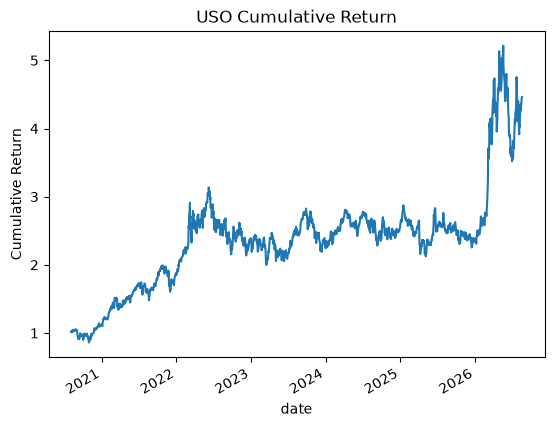

In [5]:
import matplotlib.pyplot as plt
#this is needed for the plotting

#Now plot cumulative return series for USO
df_creturns["USO"].plot()
#Even for basic plots, it is good practice to label the axes, so let's add a y-axis label
plt.ylabel("Cumulative Return")
plt.title('USO Cumulative Return')

plt.show()

#The plot is looking reasonable -- note the sharp jump in 2026 corresponding
#to the Iran crisis discussed in the motivating example above


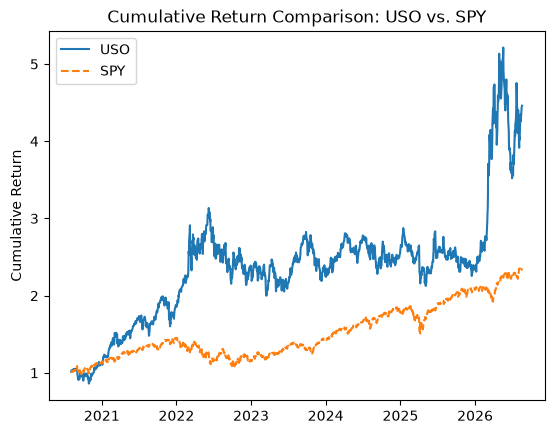

In [6]:
#Now plot cumulative return series for USO and SPY together for comparison
plt.plot(df_creturns['USO'], label='USO', linestyle='-')
plt.plot(df_creturns['SPY'], label='SPY', linestyle='--')
#Even for basic plots, it is good practice to label the axes, so let's add a y-axis label
plt.ylabel("Cumulative Return")
plt.title('Cumulative Return Comparison: USO vs. SPY')
plt.legend()

plt.show()

Some questions / insights based on the previous figures:

1. USO's cumulative return path is far more volatile than SPY's, with a sharp, dramatic jump around the 2026 Iran crisis discussed earlier -- but also several other sharp moves over the sample period. What other real-world events might explain some of the earlier swings in USO's cumulative return (e.g., in 2021 and 2022)?
2. Over this roughly six-year window, USO's cumulative return substantially exceeds SPY's. Does this mean oil was simply a "better investment" than the broad stock market? What would the CAPM say about how risk and expected return should relate to one another, and how might USO's much higher volatility -- along with the fact that it is a futures-based product rather than a claim on a diversified basket of productive businesses -- complicate a naive "higher return means better investment" comparison? (We'll return to the CAPM and risk-return tradeoffs in the next class session.)
3. Notice that SPY's cumulative return path looks comparatively smooth through the window shown here -- but keep this notebook's very first chart in mind. SPY was not immune to sudden shocks over the full sample; it just happened not to be the epicenter of *this particular* crisis.



## Statistical Properties of USO and SPY Returns

Now that we have constructed a dataset of daily returns for our two securities -- USO (oil) and SPY (the broad stock market) -- we are ready to compute some basic statistics and gain insight regarding some of the properties of their returns.

As a first cut, let's look at the simple 'off the shelf' summary statistics produced by Pandas 'describe' functionality. Note that prior to computing the statistics I re-scale the returns to be in percentage units.

This 'off-the-shelf' application of .describe() gives the number of observations (count), mean, standard deviation (std), min, max, and several "quantiles" of the distribution of returns (25th, 50th, and 75th percentiles).

Questions:

1. What are the units for the mean and standard deviation? How might you further transform these to obtain more meaningful or interpretable numbers?
2. The minimum and maximum returns are useful for detecting potential data problems. Do these values seem reasonable to you?

In [7]:
df_returns_percent = 100*df_returns
df_returns_percent.describe()

,USO,SPY
count,1518.000000,1518.000000
mean,0.124914,0.061552
std,2.293995,1.060198
min,-11.658668,-5.854295
25%,-1.184650,-0.454604
50%,0.160880,0.082854
75%,1.460921,0.637173
max,12.937390,10.501934



In this case, we do not see any "crazy" returns and the statistics seem reasonable.

### Key Insights

1. The mean daily return is higher for USO (about 0.12% per day) than for SPY (about 0.06% per day) over this sample -- consistent with oil's substantially larger risk over the same period.
2. The standard deviation of daily returns is much larger for USO (about 2.3%) than for SPY (about 1.1%) -- USO is roughly twice as volatile as the broad stock market on a typical day. As with the mean, note that the standard deviation of daily returns is much larger than the mean for both securities. This captures the idea that fluctuations over very short horizons are very difficult to forecast -- we expect this in informationally efficient asset markets (we will discuss this concept in more detail later).
3. The extreme values are striking for both securities: USO ranges from about -11.7% to +12.9% in a single day, and SPY -- despite being a diversified index -- still ranges from about -5.9% to +10.5% in a single day. We'll return to SPY's most extreme day later in the notebook.

Although the .describe() functionality is useful, we now want to compute some additional statistics, beyond those reported in the above table, and produce a custom table that summarizes the key information and insights. 

## "Moments" of a random variable and corresponding statistics

Up to this point, we have been relatively informal regarding probability and statistics, relying on common and intuitive statistics and their interpretations. But, it is time to get a bit more formal about this. Therefore, let us remind ourselves of some basic concepts in probability. *Note: Here I assume familiarity with some probability ideas including random variables, distribution functions, density functions, etc. If you need a review, consult the textbook from your probability and statistics class.*

### Mean and Variance/Std deviation

The **expected value** or **mean** of a random variable is the average value. Mathematically, $E(X) = \int_{-\infty}^{\infty} x f(x) dx$, where $f(x)$ is the density function for the random variable (in the case of a discrete random variable the integral becomes a sum over possibly values and f(x) is the probability mass function). Sometimes we use the symbol $\mu$ for the mean or expectation, e.g., $\mu_{X}$ denotes the mean of the random variable $X$. 

The mean of a distribution is sometimes called the **first moment**. It is a measure of the "center of mass" of the distribution.  

The key "sample moments" for returns (or any data series) is the sample mean:

Mean or sample average: $\bar{R} \equiv (1/T)\sum_{t=1}^{T} R_{t}$


The **variance** of a random variable is the expected value of the squared deviation of the variable from its mean. Mathematically, $Var(X) = \sigma^{2}(X) = E[(X-\mu_{x})^{2}]=\int_{-\infty}^{\infty} (x-\mu_{x})^{2} f(x) dx$, where $\mu_{X}$ is the mean of $X$. 

The variance is the **second (centered) moment** of a random variable. It is a measure of the *dispersion* of a random variable. The square root of the variance is the standard deviation: $\sigma(X) = \sqrt{\sigma^{2}(X)}$. The standard deviation is in the same units as the underlying variable, e.g., monthly \% for returns, which makes it easier to interpret relative to the variance.

Similarly to the mean, we can construct a natural "plug-in" estimate of the variance: $s^2 \equiv (1/T)\sum_{t=1}^{T} (R_{t} - \bar{R})^{2}$.

*Technical note*: in contrast to the sample mean, the sample variance defined above is actually slightly biased even for i.i.d. returns. To obtain an unbiased variance estimate, we can divide the sum of squared deviations by $T-1$ rather than $T$, which represents a "degree of freedom" correction reflecting the fact that we used the data once to obtain an estimate of the (unknown) true mean.

### Higher moments (Skew and Kurtosis)

We can also consider other **higher moments**. The most common two are the **skewness (or skew)** and **kurtosis**, which are the third and fourth centered moments, respectively.

$\text{Skew}(X) =  \frac{E[(X-\mu_{x})^{3}]}{\sigma(X)^{3}}$. The skew is a measure of the degree of *asymmetry* in a distribution. The normal distribution has a skew of zero -- it is a symmetric distribution. 

As a real-life example of a skewed random variable, consider the payoff to the state lottery. This random variable is (positively) skewed: with high probability there is a small loss, but with a very small probability there is an extremely large gain.

$\text{Kurt}(X)  = \frac{E[(X-\mu_{x})^{4}]}{\sigma(X)^{4}}$. The kurtosis is a measure of "fatness of the tails" of a distribution. The normal distribution is a key reference. It has a kurtosis equal to 3. Distributions with a kurtosis higher than 3, such as "student's-$t$" distribution, are considered "fat-tailed". Under such distributions, extreme outcomes occur with higher probability relative to the normal distribution. 

The above moments are "population" features -- they describe the true distribution. For example, if we *know* that a particular random variable is normally distributed, then its skewness equals zero and its kurtosis equals 3. But what if instead we *observe data from an unknown distribution*? This case is generally more realistic. In such cases, we use observed data to *estimate* the unknown population moments.



(Sample) skewness: $\widehat{\text{Skew}} \equiv \frac{\frac{1}{T}\sum_{t=1}^{T} (R_{t} - \bar{R})^{3}} {(s^{2})^{3/2}}$

(Sample) kurtosis: $\widehat{\text{Kurt}} \equiv \frac{\frac{1}{T}\sum_{t=1}^{T} (R_{t} - \bar{R})^{4}} {(s^{2})^{2}}$

The above estimates take a relatively simple "plug-in" form. Basically, when we do not know a quantity, we "plug-in" the sample analog of the quantity. For example, when we do not know the true variance, we "plug-in" the sample variance.


Pandas allows a simple way to compute these statistics individually. Suppose, for example, that we want the sample skewness for each of the return series. Then we can use the ".skew()" method in Python:


In [8]:
df_returns.skew()

USO   -0.162090
SPY    0.198618
dtype: float64

The skewness estimates are modest in magnitude for both securities: USO's daily returns are slightly negatively skewed (about -0.16) while SPY's are slightly positively skewed (about +0.20) over this sample. Interestingly, this SPY result runs the opposite direction from a commonly cited stylized fact -- that stock index returns tend to be *negatively* skewed over long historical samples, reflecting that market crashes tend to be sharper and more sudden than rallies. This is a useful reminder that skewness, estimated from a finite and relatively short sample, can be quite noisy, and depends heavily on which specific episodes happen to be included in the window.

*The homework assignment that follows this notebook will push further and teach you how to construct standard errors (measures of precision) for these skew estimates and to test the null hypothesis that the true skewness equals zero.*

For the kurtosis, we can likewise do:

In [9]:
df_returns.kurt()

USO    2.834306
SPY    8.196598
dtype: float64

*Important note*: Pandas .kurt() function computes the kurtosis using "Fisher’s definition of kurtosis" -- this is basically the kurtosis formula above with 3 (the kurtosis of the normal distribution) *subtracted*. Sometimes this is called the "excess kurtosis", meaning in excess of that for the normal distribution.

Thus, the positive values should be interpreted as indicating that the returns are more "fat-tailed" than the normal distribution. This is a well-known result that holds across many assets. Financial returns tend to have "fat tails" and produce extreme outcomes more often than predicted under the normal distribution. The result is important in areas such as risk management and in the regulation of financial institutions. 


### Constructing and presenting a (custom) summary statistics table

Earlier, we used Pandas .describe() method to produce a set of statistics for our return data. The statistics produced included the mean and standard deviation, but did not include estimates of the skewness and kurtosis. Now let us construct instead a "custom" statistics table that is also nicely formatted.

There are various ways to do this in Python. In this case, I will make use of the 'agg' method as a convenient way to get a set of custom statistics including sample skew and kurtosis. Finally, we will spit everything out in a reasonably nice table format.

In [10]:
summarydf = df_returns_percent.agg(['min','max','mean','median','std','skew','kurt','count'])

# Change the row indexes to nicer labels
summarydf.index = ['Min', 'Max', 'Mean', 'Median', 'Std. Dev.', 'Skew', 'Kurt', 'N']
summarydf

,USO,SPY
Min,-11.658668,-5.854295
Max,12.937390,10.501934
Mean,0.124914,0.061552
Median,0.160880,0.082854
Std. Dev.,2.293995,1.060198
Skew,-0.162090,0.198618
Kurt,2.834306,8.196598
N,1518.000000,1518.000000


The above is a reasonably good tabulation of summary statistics. But it could be improved for presentation. There is no title, for example. In addition, there are arguably too many decimal places displayed. If we want to include this table in a presentation or paper, we should reduce the precision to make it easier for the reader to glean the important information. 

One option would be to export this dataframe into, e.g., Excel or Word and then make additional formatting edits by hand. But that is inefficient and brings potential errors into play. Let's instead use Pandas 'styling' capabilities for dataframes. The following code sets the decimal precision at 3 and adds a descriptive title/caption to help the reader know exactly what is being presented.


In [11]:
summarydf.style.format('{0:,.3f}').set_caption("Summary Statistics for Daily USO and SPY Returns, 2020-2026. Note: Kurtosis is reported in excess of 3.")

,USO,SPY
Min,-11.659,-5.854
Max,12.937,10.502
Mean,0.125,0.062
Median,0.161,0.083
Std. Dev.,2.294,1.060
Skew,-0.162,0.199
Kurt,2.834,8.197
N,"1,518.000","1,518.000"


### More Insights and Questions

What can we learn from the above table about the properties of USO and SPY returns, beyond our earlier insights?

1. USO's skew (-0.16) and SPY's skew (+0.20) are both modest in magnitude and opposite in sign. As noted above, this SPY result runs counter to the commonly cited stylized fact that equity index returns are negatively skewed over long samples -- a good reminder that short-sample skewness estimates should be interpreted cautiously.
2. Both securities show substantial positive excess kurtosis -- USO's is about 2.8, and SPY's is, perhaps surprisingly, even larger at about 8.2. Both indicate fat tails relative to the normal distribution: extreme outcomes occur more often than the normal distribution would predict.
3. SPY's very high kurtosis estimate is a useful cautionary example. A summary statistic like kurtosis is extremely sensitive to a small number of extreme observations -- and, as we'll see in the Q-Q plots below, SPY's kurtosis is driven substantially by a single remarkable trading day.

**Questions** (for you):

1. Is it appropriate to conclude from the table above that USO returns are meaningfully negatively skewed? Explain your reasoning.
2. USO's excess kurtosis is smaller than SPY's, yet USO's return distribution seems, informally, like it *should* be the more extreme one, given everything discussed in this notebook so far. Keep this puzzle in mind as you look at the Q-Q plots below.

Summary statistics like the mean, standard deviation, skewness, and kurtosis are useful, compact descriptions of a distribution -- but they can also obscure important structure. A single extreme observation can dominate a moment-based statistic like kurtosis, without that showing up clearly as a single memorable number. A complementary, and often more revealing, approach is to *look at the data directly* using a graphical diagnostic. That's where we turn next.


## Informal Assessment of Distributional Shape: Q-Q Plots

So far, we've assessed departures from normality indirectly, through summary statistics like skewness and kurtosis. A more direct, visual way to assess whether a variable looks normally distributed is the **quantile-quantile (Q-Q) plot**.

The idea is simple: if we sort our $T$ observed returns from smallest to largest, each one corresponds to a particular *sample quantile* (e.g., the smallest observation is roughly the $1/T$ quantile, the largest is roughly the $(T-1)/T$ quantile). A Q-Q plot compares each observed value against the value we *would expect* at that same quantile *if the data were exactly normally distributed* (using the sample mean and standard deviation to pin down which normal distribution). If the data really were normal, every point would fall almost exactly on a straight 45-degree reference line. Systematic deviations from that line tell us, quite precisely, *how* and *where* the data depart from normality:

- Points curving *below* the line at the low end (the left tail) mean the most negative returns are more extreme than a normal distribution would predict.
- Points curving *above* the line at the high end (the right tail) mean the most positive returns are more extreme than a normal distribution would predict.
- An S-shaped (or "banana-shaped") pattern -- below the line on the left, above the line on the right -- is the classic visual signature of *fat tails*, exactly what positive excess kurtosis indicates numerically.

This is *informal* inference in the sense that we are not computing a formal test statistic or p-value -- we are visually assessing a null hypothesis (normality) using a picture. It's a good complement to the formal statistical tools you'll build up in a later class session: a Q-Q plot can reveal exactly *where* in the distribution a departure from normality is occurring, which a single summary number like kurtosis cannot.


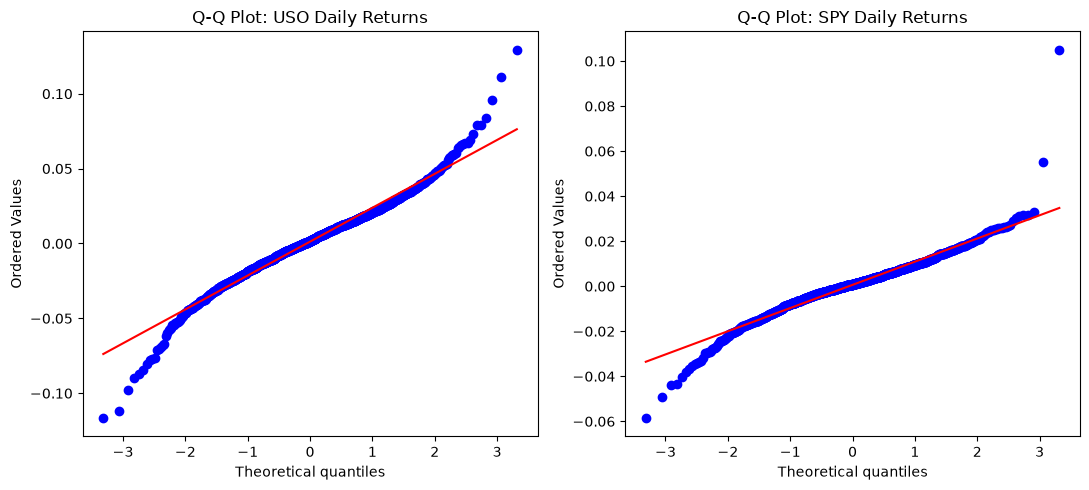

In [12]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, col in zip(axes, ["USO", "SPY"]):
    stats.probplot(df_returns[col], dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot: {col} Daily Returns")

plt.tight_layout()
plt.show()

Both Q-Q plots show a clear S-shaped departure from the straight reference line -- neither USO nor SPY daily returns look normally distributed over this sample. But look closely at *how* they differ:

- **USO**'s departure is broad and systematic: points begin bowing away from the line well before the most extreme quantiles, on both the left and right tails, and the most extreme points sit far above/below where a normal distribution would put them. This is consistent with a return series that experiences large, sudden moves *repeatedly* -- exactly what we'd expect from a security whose price is tied to a commodity that has been jolted by several distinct crises over this sample (2021, 2022, and of course 2026).
- **SPY**'s departure is more concentrated: most of the distribution actually hugs the reference line reasonably well, with the most dramatic deviation coming from just a handful of isolated points at the very extremes -- most strikingly, the single highest point in the upper right, which corresponds to SPY's remarkable +10.5% single-day gain in April 2025. That one day, on its own, is doing a great deal of work in the excess-kurtosis number we computed earlier (about 8.2) -- a nice illustration of why it's dangerous to summarize an entire distribution with a single number, and why looking at the data graphically is such a valuable complementary habit.

This resolves the puzzle from a moment ago: SPY's kurtosis *statistic* is larger than USO's, but that's substantially an artifact of one extraordinary day, not evidence that SPY's *typical* behavior is more extreme than USO's. The Q-Q plot -- by showing the *entire* distribution rather than compressing it into one number -- makes this distinction visible in a way that skewness and kurtosis alone cannot.

## Takeaways

Let's step back and take stock of what the empirical evidence in this notebook actually shows.

Across both USO (oil) and SPY (the broad stock market), and using a genuinely long sample (roughly six years of daily data), we found:

- Both securities show non-trivial skewness -- modest in magnitude, but of opposite sign for USO and SPY over this particular sample.
- Both securities show substantial positive excess kurtosis: USO's is about 2.8 and SPY's is about 8.2, both well above the value of 0 (i.e., a kurtosis of 3) implied by the normal distribution.
- The Q-Q plots make this concrete and visual: both return series show a systematic S-shaped departure from the 45-degree reference line that a normally distributed variable would trace out.

Taken together, this evidence points to a single, fairly firm conclusion: **daily returns on these securities are not well described by a normal distribution.** This is not a minor technicality. The normal distribution assigns vanishingly small probability to large moves -- multi-standard-deviation daily returns of the kind we saw repeatedly in this notebook (for USO, and even for SPY on its most extreme day) should, under normality, be almost impossible to observe. Real financial markets clearly do not work this way.

**Why this matters for risk management.** If a bank, asset manager, or trading desk incorrectly assumes normally distributed returns -- for example, in computing a Value-at-Risk figure, sizing a hedge, or pricing an option -- it will systematically *underestimate* the probability and severity of large losses. Fat tails mean that "once-in-a-lifetime" events, under a normal-distribution assumption, actually occur with meaningful regularity in practice. Getting this wrong is not merely a statistical curiosity: mismeasured tail risk of exactly this kind has been directly implicated in a number of real financial crises and institutional failures.

**An open question.** This notebook has focused on establishing *that* the normal distribution is inappropriate for daily returns -- but it has deliberately left open the more difficult question of *what a more appropriate model would look like*. We'll close by briefly and informally pointing to two (not mutually exclusive) directions, both of which we'll develop more formally later in the course:

1. **Use a different statistical distribution that permits skewness and excess kurtosis.** The Student's-$t$ distribution, mentioned earlier in this notebook, is one classic example: it looks like a normal distribution but with heavier tails (controlled by a "degrees of freedom" parameter), and skewed variants exist as well. Choosing a better-fitting distribution is a direct, relatively simple fix -- but it treats fat tails as simply a feature of the unconditional distribution of returns, without explaining *why* returns behave this way.
2. **Recognize that fat-tailed behavior can emerge from *stochastic volatility*.** Instead of assuming returns are drawn from one fixed (fat-tailed) distribution, suppose that returns are *conditionally* normally distributed, but with a variance that itself fluctuates randomly -- and often *persistently* -- over time (calm periods cluster together, turbulent periods cluster together). Averaged over time, this kind of "mixture" of calm and turbulent normal distributions produces exactly the fat-tailed, excess-kurtosis behavior we documented above, even though returns are normal *conditional on* the current volatility regime. This is a much richer, more economically intuitive explanation -- and it is also directly testable and forecastable.

Later in the course, we will take up the second explanation in depth, when we cover measuring, modeling, and forecasting volatility (including GARCH-type models). For now, the main takeaway is simply this: **the normal distribution is a convenient starting point, but the evidence in this notebook shows clearly that it is not the right destination.**
